# LAPD Crime Data Analysis (2020–2024)

This notebook analyzes crime incidents reported in Los Angeles between 2020 and 2024. I originally started this project using the Manitoba Rabies dataset, but after completing the initial exploration, it became clear that the dataset didn’t have enough depth or variation for meaningful data cleaning or analysis. 

The LAPD dataset provides a much stronger foundation for this course because it includes detailed information such as crime type, date and time, area, victim demographics, premises, weapon involvement, and geographic coordinates. It also contains real-world inconsistencies and missing values, which makes it more suitable for demonstrating proper data wrangling and exploratory analysis.

Because the full dataset is very large, I will be using a smaller random subset (`df_small`) for all analysis so the notebook runs efficiently while still reflecting realistic patterns in the data.


## 1. Initial Exploration

In [4]:
# Week 12: Initial dataset loading and inspection
# Purpose: Load the dataset and perform basic structural checks.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Python can see the src/ folder
import sys
sys.path.insert(0, '..')

# Import the helpers module from src
from src import helpers

df = pd.read_csv(r"C:\Users\fpasha\OneDrive - Red River College Polytech\COMP-2040\final_project\data\Crime_Data_from_2020_to_2024.csv")

df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


### 1.1 Dataset Shape

In [5]:
# Just checking the size of the dataset so I know how many rows and columns I'm working with.
df.shape


(1004894, 28)

### 1.2 Column Types and Missing Values


In [6]:
# Using .info() to get a quick overview of the dataset's structure.
# This shows me the column names, their data types, and how many non-null values each column has.
# Basically, I'm checking for any obvious issues like missing data or wrong data types before I go deeper.

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

#### 1.2.1 Missing Values Breakdown


In [7]:
# Quick breakdown of missing values in each column so I can see which parts of the dataset need cleaning later.
df.isnull().sum()


DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64

### 1.3 Descriptive Statistics


In [8]:
# Quick summary stats for the numeric columns so I can spot weird ranges or outliers.
df.describe()


,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004878e+06,327216.000000,1.004883e+06,69154.000000,2314.000000,64.00000,1.004894e+06,1.004894e+06
mean,2.202190e+08,1.339901e+03,1.069153e+01,1.115613e+03,1.400313e+00,5.001386e+02,2.891862e+01,3.056108e+02,363.950797,4.998992e+02,958.097796,984.015990,991.21875,3.399820e+01,-1.180908e+02
std,1.319070e+07,6.510761e+02,6.110248e+00,6.111596e+02,4.899620e-01,2.052638e+02,2.199267e+01,2.192913e+02,123.737665,2.050643e+02,110.358509,52.350982,27.06985,1.610789e+00,5.582654e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106168e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209158e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311102e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521040e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


### 1.4 Initial Observations

- The dataset is **huge** with a little over **1 million rows**, so I need to be aware of performance when I start doing heavier operations.
- A few columns are basically useless. **Crm Cd 2**, **Crm Cd 3**, and **Crm Cd 4** are almost completely empty, so they probably won’t help with anything.
- The weapon fields have a ton of missing values. **Weapon Used Cd** and **Weapon Desc** are missing around **677k rows**, which tells me most incidents either didn’t involve a weapon or the info wasn’t recorded.
- **Vict Sex** and **Vict Descent** both have around **144k missing values**, which is a lot. I’ll need to figure out how to handle that later since those fields matter for analysis.
- **Cross Street** is missing more than **850k rows**, so the street level detail is weak. I’ll probably rely more on the `LAT` and `LON` columns instead.
- I noticed some weird values in the numeric summary. **Vict Age** goes down to `-4`, which obviously isn’t valid and will need cleaning.
- **LON** has a max value of `0`, which doesn’t make sense for LA. That looks like a placeholder or a bad entry that I’ll need to fix.


### 1.5 Analytical Questions

- What types of crimes are the most common in this dataset, and how do they compare when I group them by the `Crm Cd Desc` column?
- How does crime activity change by time of day? I want to look at patterns using the `TIME OCC` column to see when incidents happen the most.
- Are certain areas reporting more incidents than others? I want to compare crime counts across different `AREA NAME` values to see which parts of the city stand out.


## 2. Data Cleaning

### 2.1 Fix invalid ages
The `Vict Age` column has some values that are negative. That obviously isn’t possible, so these rows would mess up any age‑based analysis. I’m treating any age below 0 as missing because it keeps the dataset clean and avoids pulling wrong conclusions later.


In [9]:
# Some rows have negative ages like -4, which isn't realistic.
# These values would mess up any analysis involving victim age,
# so I'm replacing any age below 0 with NaN to mark them as missing.
df['Vict Age'] = df['Vict Age'].apply(lambda x: x if x >= 0 else None)


### 2.2 Remove invalid longitude values
The `LON` column has some values that are `0`, which doesn’t make sense for Los Angeles. Real LA coordinates should be around -118, so a longitude of 0 basically means the location wasn’t recorded properly. These rows would mess up any mapping or location analysis, so I’m removing them now to keep the dataset clean.


In [10]:
# Removing rows where LON is 0 because that isn't a real coordinate for LA.
# Keeping these rows would cause problems later when I try to map or analyze
# crime locations, since a longitude of 0 would place the point somewhere
# in the Atlantic Ocean. Dropping them now keeps the dataset consistent.
df = df[df['LON'] != 0]


### 2.3 Drop columns that are basically empty
The columns `Crm Cd 2`, `Crm Cd 3`, and `Crm Cd 4` are almost completely empty. They barely contain any real data, so keeping them won’t add anything useful to the analysis. Dropping them now keeps the dataset cleaner and makes it easier to focus on the columns that actually matter.


In [11]:
# Dropping Crm Cd 2, 3, and 4 because they are almost entirely empty.
# These columns don't provide any meaningful information and would just
# clutter the dataset, so removing them now keeps things cleaner and easier
# to work with for the rest of the project.
df = df.drop(columns=['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'])


### 2.4 Convert date columns to datetime
The `Date Rptd` and `DATE OCC` columns are stored as strings right now. Converting them to proper datetime objects makes it easier to work with dates later, especially if I want to look at trends over time. Using `errors='coerce'` also helps because any bad or weird date formats will automatically turn into `NaT` instead of breaking the code.


In [12]:
# Converting the date columns from strings into proper datetime objects.
# This makes it easier to filter by date, extract things like year or month,
# and run any time-based analysis later on. Using errors='coerce' makes sure
# that any invalid or messy date entries get turned into NaT instead of causing errors.
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')


C:\Users\fpasha\AppData\Local\Temp\ipykernel_3116\279976682.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')
C:\Users\fpasha\AppData\Local\Temp\ipykernel_3116\279976682.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')


**Note about the date parsing warning:**  
Pandas showed a warning saying it couldn't infer the exact date format and had to fall back to a slower parser. The important part is that the conversion still worked because the dates in this dataset are already in a standard `YYYY-MM-DD` format. Since pandas successfully converted both `Date Rptd` and `DATE OCC` into proper datetime values, I don’t need to specify a manual format or change anything here.


### 2.5 Handle missing values
A few columns in this dataset have missing values, but not all of them need to be filled. Some fields like `Cross Street` or `Weapon Used Cd` are naturally incomplete because not every crime report includes that information. For this project, I’m only fixing the columns where the missing values are small and easy to handle. The goal here is to clean up obvious gaps without changing the meaning of the data.


In [13]:
# Handling missing values in a few key columns.
# Some columns naturally have missing data (like Cross Street or Weapon Used Cd),
# so I'm leaving those as-is. But for columns where the missing values are small
# and easy to fix, I'm filling them with a simple placeholder to keep things consistent.

# Filling missing Premis Cd with -1 to mark "unknown" without dropping rows.
df['Premis Cd'] = df['Premis Cd'].fillna(-1)

# Filling missing Status values with "UNKNOWN" so the column stays usable.
df['Status'] = df['Status'].fillna('UNKNOWN')


**Note:** I used `-1` for missing values in `Premis Cd` because it’s a numeric code column, and using a number keeps the column consistent without dropping any rows. For `Status`, I used `"UNKNOWN"` since that column is text-based, and filling it with a string keeps it readable and easy to work with. Both choices keep the dataset clean without changing the meaning of the data.


## 3. Helper Module

### 3.1 Create helper module
To keep the notebook organized, I’m creating a separate Python file called `helpers.py`. This file will store small reusable functions that I can import and use throughout the analysis. For now, I’m adding a simple test function to confirm that the module loads correctly.


In [14]:

helpers.hello()


'helpers.py is working'

### 3.2 Add basic helper functions
Now that the helper module is created, I’m adding a few small reusable functions to keep the notebook cleaner. These functions handle common tasks like filtering by year, counting values in a column, and getting the top N categories. Each function includes a clear docstring explaining what it does, what it takes in, and what it returns.


### 3.3 Test helper functions
Now that the helper functions are added, I’m importing the module and running a few quick tests to make sure everything works as expected. This confirms that the functions load properly and return the kind of output I need for the analysis section.


In [15]:

# Testing filter_by_year to make sure it returns only rows from the year I specify.
# If this works, I should see a DataFrame preview with DATE OCC values from 2020 only.
helpers.filter_by_year(df, 2020).head()


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,Cross Street,LAT,LON
0,211507896,2021-04-11,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,2020-12-24,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,STREET,NaN,NaN,IC,Invest Cont,331.0,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,2020-10-03,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,ALLEY,NaN,NaN,IC,Invest Cont,420.0,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [16]:
# Testing count_by_column to confirm it produces a clean frequency table.
# This helps me quickly check which crime descriptions appear the most.
helpers.count_by_column(df, 'Crm Cd Desc').head()

Crm Cd Desc
VEHICLE - STOLEN                                           115127
BATTERY - SIMPLE ASSAULT                                    74465
BURGLARY FROM VEHICLE                                       63460
THEFT OF IDENTITY                                           62511
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     61028
Name: count, dtype: int64

In [17]:
# Testing top_n to verify it returns the top N most common values in a column.
# This is useful later when I summarize which areas have the most incidents.
helpers.top_n(df, 'AREA NAME')

AREA NAME
Central        69474
77th Street    61623
Pacific        59340
Southwest      57369
Hollywood      52107
N Hollywood    51014
Olympic        49940
Southeast      49788
Newton         49075
Wilshire       48106
Name: count, dtype: int64

### 3.4 Add one more helper function
To support the analysis section, I added a small grouping helper that counts how many rows fall into each category of a column. This will be useful later when summarizing incidents by area, crime type, or year. It keeps the notebook cleaner by avoiding repeated groupby logic.


In [18]:
# Testing group_and_count to confirm it returns a sorted summary table.
helpers.group_and_count(df, 'AREA NAME').head()


AREA NAME
Central        69474
77th Street    61623
Pacific        59340
Southwest      57369
Hollywood      52107
dtype: int64

### 3.5 Summary of the Helper Module

To keep the notebook clean and focused on the analysis, I moved repeated logic into a separate helper module located in `src/helpers.py`. This module now contains reusable functions for filtering by year, counting values in a column, getting the top N categories, and grouping data to produce quick summaries. Each function includes a clear docstring explaining what it does, its parameters, and what it returns. Using a helper module makes the workflow easier to maintain and keeps the analysis section readable by hiding low‑level operations that don’t need to appear in the main notebook.


## 4. Data Cleaning

### 4.1 Identify Cleaning Tasks
Before cleaning the dataset, I reviewed the results from Section 2 to identify the specific issues that need to be fixed. Based on the exploration, the main cleaning tasks are:

- Convert date columns to proper datetime format.
- Remove rows where the date could not be parsed.
- Extract useful time-based features such as year, month, and hour.
- Standardize text columns (strip whitespace, fix casing, handle inconsistent labels).
- Handle invalid ages (e.g., 0 or extremely high values).
- Remove or handle rows with missing or invalid coordinates.
- Drop columns that are not useful for analysis or have too many missing values.
- Ensure all categorical fields are consistent and ready for grouping/visualization.

These tasks will prepare the dataset for the analysis and visualizations in Week 14.


In [19]:
# 4.2 Data Cleaning - Step 1: Clean and extract date information

# Make a copy so we don't modify the original df accidentally
clean_df = df.copy()

# Convert the date column to datetime
clean_df['DATE OCC'] = pd.to_datetime(clean_df['DATE OCC'], errors='coerce')

# Drop rows where the date could not be parsed
clean_df = clean_df.dropna(subset=['DATE OCC'])

# Extract useful time features
clean_df['YEAR'] = clean_df['DATE OCC'].dt.year
clean_df['MONTH'] = clean_df['DATE OCC'].dt.month
clean_df['HOUR'] = clean_df['DATE OCC'].dt.hour

clean_df.head()


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,Cross Street,LAT,LON,YEAR,MONTH,HOUR
0,211507896,2021-04-11,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,7800 BEEMAN AV,NaN,34.2124,-118.4092,2020,11,0
1,201516622,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,ATOLL AV,N GAULT,34.1993,-118.4203,2020,10,0
2,240913563,2024-12-10,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,14600 SYLVAN ST,NaN,34.1847,-118.4509,2020,10,0
3,210704711,2020-12-24,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,6000 COMEY AV,NaN,34.0339,-118.3747,2020,12,0
4,201418201,2020-10-03,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020,9,0


### Cleaning Step 1: Date Parsing and Feature Extraction
I converted the DATE OCC column into a proper datetime format and removed rows where the date could not be parsed. Then I extracted the YEAR, MONTH, and HOUR fields, which will be useful for time‑based analysis later in the project.


### 4.2 Clean Invalid Ages
The `Vict Age` column contains unrealistic values such as 0, negative numbers, or ages above 100. These values would distort any age‑based analysis, so they need to be handled before moving forward. My goal here is to make the age field reliable without removing too much data.


In [20]:
# 4.2 Clean Invalid Ages

# Convert Vict Age to numeric in case it was read as a string.
# Using errors='coerce' turns anything non-numeric into NaN, which is easier to handle.
clean_df['Vict Age'] = pd.to_numeric(clean_df['Vict Age'], errors='coerce')

# Identify unrealistic ages.
# Ages <= 0 or > 100 are not meaningful for analysis and should be treated as missing.
invalid_age_mask = (clean_df['Vict Age'] <= 0) | (clean_df['Vict Age'] > 100)

# Replace invalid ages with NaN so they don't influence averages or distributions.
clean_df.loc[invalid_age_mask, 'Vict Age'] = pd.NA

# -----------------------------
# VERIFICATION: PROVE IT WORKED
# -----------------------------

# 1. Check if any invalid ages remain after cleaning.
remaining_invalid = clean_df[(clean_df['Vict Age'] <= 0) | (clean_df['Vict Age'] > 100)]
print("Remaining invalid ages (should be empty):")
display(remaining_invalid)

# 2. Quick summary to confirm the column looks reasonable.
clean_df['Vict Age'].describe()


Remaining invalid ages (should be empty):


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,Cross Street,LAT,LON,YEAR,MONTH,HOUR


count    733886.000000
mean         39.504285
std          15.571505
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: Vict Age, dtype: float64

### Cleaning Step 2: Why I Cleaned Ages This Way
I chose to convert the `Vict Age` column to numeric and replace unrealistic values with `NaN` because incorrect ages would distort any age‑related patterns in the analysis. Values like 0, negative ages, or extremely high ages are not meaningful in this context, so treating them as missing is the safest option. I also added a verification step to confirm that no invalid ages remain after cleaning. This approach keeps the dataset realistic without removing entire rows, which helps preserve as much information as possible for the later analysis.


### 4.3 Clean Invalid Coordinates
The dataset includes latitude and longitude values, but some rows contain zeros or missing coordinates. These rows cannot be mapped or used in any spatial analysis, so they need to be handled. My goal here is to remove only the rows with clearly invalid coordinates while keeping the rest of the dataset intact.


In [21]:
# 4.3 Clean Invalid Coordinates

# LAT and LON should never be zero in real-world GPS data.
# Zero coordinates usually mean missing or invalid entries.
invalid_coord_mask = (clean_df['LAT'] == 0) | (clean_df['LON'] == 0)

# Replace invalid coordinates with NaN so they can be handled consistently.
clean_df.loc[invalid_coord_mask, ['LAT', 'LON']] = pd.NA

# --------------------------------
# VERIFICATION: PROVE IT WORKED
# --------------------------------

# 1. Check if any rows still contain zero coordinates.
remaining_invalid_coords = clean_df[(clean_df['LAT'] == 0) | (clean_df['LON'] == 0)]
print("Remaining invalid coordinates (should be empty):")
display(remaining_invalid_coords)

# 2. Quick summary to confirm the columns look reasonable.
clean_df[['LAT', 'LON']].describe()


Remaining invalid coordinates (should be empty):


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,Cross Street,LAT,LON,YEAR,MONTH,HOUR


,LAT,LON
count,1.002654e+06,1.002654e+06
mean,3.407415e+01,-1.183547e+02
std,1.111551e-01,1.044427e-01
min,3.370590e+01,-1.186676e+02
25%,3.401540e+01,-1.184309e+02
50%,3.405920e+01,-1.183230e+02
75%,3.416490e+01,-1.182740e+02
max,3.433430e+01,-1.181554e+02


### Cleaning Step 3: Why I Cleaned Coordinates This Way
Latitude and longitude values of zero are not valid for Los Angeles and usually indicate missing data. Instead of dropping entire rows immediately, I replaced invalid coordinates with `NaN` so they can be handled consistently with other missing values. I also added a verification step to confirm that no zero coordinates remain. This keeps the dataset clean for any mapping or spatial analysis later in the project.


### 4.4 Standardize Text Columns
Several columns in the dataset contain text values that are inconsistent due to casing differences, trailing spaces, or formatting issues. These inconsistencies can cause problems when grouping, counting, or visualizing categories. The goal here is to standardize all major text fields so they are clean, consistent, and ready for analysis.


In [22]:
# 4.4 Standardize Text Columns

# These are the main text-based columns that usually have messy formatting.
# A lot of them come in with mixed casing (upper/lower), random spaces at the start/end,
# or even the literal string "nan" because of how the CSV was exported.
# Cleaning these now prevents issues later when I group or count categories.
text_columns = [
    'AREA NAME', 'Crm Cd Desc', 'Vict Sex', 'Vict Descent',
    'Premis Desc', 'Weapon Desc', 'Status Desc'
]

# Loop through each text column and apply consistent formatting.
# I'm converting everything to string first because some columns might contain numbers or NaN.
# Then I strip whitespace so categories like " THEFT" and "THEFT " don't get treated as different.
# Finally, I convert everything to uppercase because LAPD categories are usually uppercase,
# and this keeps the dataset consistent for grouping and visualization.
for col in text_columns:
    if col in clean_df.columns:
        clean_df[col] = (
            clean_df[col]
            .astype(str)          # Make sure everything is treated as text
            .str.strip()          # Remove leading/trailing spaces
            .str.upper()          # Standardize casing for consistency
            .replace({'NAN': pd.NA})  # Replace literal "NAN" strings with actual missing values
        )

# --------------------------------
# VERIFICATION: PROVE IT WORKED
# --------------------------------

# 1. Quick check of the top categories for AREA NAME.
# This helps me confirm that the formatting looks clean and consistent.
print("Sample check for AREA NAME:")
display(clean_df['AREA NAME'].value_counts().head(10))

# 2. Check for leftover whitespace issues in a readable way.
# Instead of regex, I'm using startswith() and endswith() which are easier to understand.
leading_spaces = clean_df['AREA NAME'].str.startswith(' ')
trailing_spaces = clean_df['AREA NAME'].str.endswith(' ')

print("Rows with leading spaces (should be 0):", leading_spaces.sum())
print("Rows with trailing spaces (should be 0):", trailing_spaces.sum())


Sample check for AREA NAME:


AREA NAME
CENTRAL        69474
77TH STREET    61623
PACIFIC        59340
SOUTHWEST      57369
HOLLYWOOD      52107
N HOLLYWOOD    51014
OLYMPIC        49940
SOUTHEAST      49788
NEWTON         49075
WILSHIRE       48106
Name: count, dtype: int64

Rows with leading spaces (should be 0): 0
Rows with trailing spaces (should be 0): 0


### Cleaning Step 4: Why I Standardized Text Columns
Text columns often contain inconsistencies such as mixed casing, trailing spaces, or literal "nan" strings. These issues can break grouping operations and produce misleading category counts. I standardized the main text fields by stripping whitespace, converting everything to uppercase, and replacing invalid text values with proper `NaN`. This ensures that categories are clean and consistent before moving into the analysis and visualization stages.


### 4.5 Drop Useless or High‑Missing Columns
Before removing anything from the dataset, I first checked the percentage of missing values for every column. This helps me understand which fields are mostly empty and which ones are still useful. Columns with extremely high missingness usually don’t contribute meaningful information and only add noise to the dataset. After reviewing the missingness output, I identified a few columns that are too incomplete to support analysis. In the next code cell, I drop only those columns and then verify that the removal worked correctly.


In [23]:
# 4.5 Check missingness before dropping any columns

# Before I remove anything from the dataset, I want to get a clear picture of how complete
# each column actually is. Some columns in this dataset are known to be extremely sparse,
# while others are fully populated. Instead of guessing, I calculate the percentage of
# missing values for every column. This gives me a ranked list showing which columns are
# mostly empty and which ones are reliable.
#
# This step is important because it lets me justify why certain columns should be removed.
# If a column is 80–90% empty, it usually doesn't contribute meaningful information and
# just adds noise to the dataset. On the other hand, columns with low missingness are
# worth keeping because they can still support analysis.
#
# I'm sorting the results from highest missing percentage to lowest so I can immediately
# see the worst offenders at the top.
missing_percent = clean_df.isna().mean().sort_values(ascending=False) * 100

print("Percentage of missing values per column (sorted):")

# Showing only the top 20 columns keeps the output readable while still giving me
# enough information to make decisions. If I need more detail, I can always expand it.
missing_percent.head(20)


Percentage of missing values per column (sorted):


Cross Street      84.657419
Weapon Desc       67.448093
Weapon Used Cd    67.448093
Vict Age          26.805658
Mocodes           15.107305
Vict Descent      14.418234
Vict Sex          14.417037
Premis Desc        0.058644
Crm Cd 1           0.001097
TIME OCC           0.000000
DR_NO              0.000000
Date Rptd          0.000000
Crm Cd             0.000000
Crm Cd Desc        0.000000
Rpt Dist No        0.000000
Part 1-2           0.000000
AREA NAME          0.000000
AREA               0.000000
DATE OCC           0.000000
Premis Cd          0.000000
dtype: float64

In [24]:
# 4.5 Drop Useless or High-Missing Columns

# Now that I’ve reviewed the missingness percentages, I can make a clear decision
# about which columns should be removed. The goal here is to clean up the dataset
# by removing fields that are mostly empty or not useful for analysis.
#
# Based on the missingness results:
# - 'Cross Street' is ~85% missing, which makes it unreliable for any meaningful analysis.
# - 'Weapon Desc' and 'Weapon Used Cd' are both ~67% missing, meaning most rows do not
#   contain weapon information. Keeping these columns would introduce more noise than value.
#
# I am only dropping columns that are clearly unusable based on the data review.

columns_to_drop = [
    'Cross Street',
    'Weapon Desc',
    'Weapon Used Cd'
]

# Before dropping, I double-check that each column actually exists in the dataframe.
# This prevents errors if the dataset changes or if a column was renamed earlier.
columns_to_drop = [col for col in columns_to_drop if col in clean_df.columns]

# Drop the selected columns.
clean_df = clean_df.drop(columns=columns_to_drop)

# --------------------------------
# VERIFICATION: PROVE IT WORKED
# --------------------------------

# 1. Confirm that each column was successfully removed.
print("Columns successfully dropped:")
for col in columns_to_drop:
    print(f"{col} ->", col not in clean_df.columns)

# 2. Show the remaining columns so I can visually confirm the structure looks correct.
print("\nRemaining columns:")
clean_df.columns


Columns successfully dropped:
Cross Street -> True
Weapon Desc -> True
Weapon Used Cd -> True

Remaining columns:


Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Status', 'Status Desc', 'Crm Cd 1', 'LOCATION', 'LAT', 'LON', 'YEAR',
       'MONTH', 'HOUR'],
      dtype='object')

### Cleaning Step 5: Why I Dropped These Columns
After checking the missingness percentages, I noticed that a few columns were mostly empty and didn’t provide enough information to support any meaningful analysis. For example, `Cross Street` was missing in more than 80% of the rows, which makes it unreliable for any kind of location-based work. The weapon-related fields (`Weapon Desc` and `Weapon Used Cd`) were also missing in more than two-thirds of the dataset, so keeping them would introduce more noise than value. Instead of letting these incomplete fields clutter the dataset, I removed them to keep the structure clean and focused. This makes the later analysis easier to interpret and ensures that the variables I keep are actually useful. I also verified that the columns were successfully removed so I know the cleaning step worked as intended.


### 4.6 Final Cleaning Summary
At this point, the dataset has gone through a full cleaning workflow where I handled missing values, fixed invalid entries, standardized text fields, and removed columns that were too incomplete to be useful. Each step was done intentionally so the dataset is easier to analyze and won’t produce misleading results later on. I verified every cleaning action along the way to make sure the changes were applied correctly. The final dataset is now more consistent, more reliable, and ready for the exploratory analysis and visualization stages that come next.


## 5. Verifying the Cleaning Results
Before moving into analysis, I want to make sure that all of the cleaning steps I performed actually worked the way I intended. Verification is important because it confirms that the dataset is consistent, readable, and free from the issues I targeted earlier. In this section, I run a few simple checks to validate the structure of the cleaned dataset. This includes confirming that the column types look correct, checking that the cleaned text fields no longer contain formatting issues, and making sure the columns I removed are truly gone. These checks give me confidence that the dataset is ready for analysis in the next section.


In [25]:
# 5. Verification of Cleaning Results

# At this point, I want to double-check that the dataset is actually in the clean state
# I expect it to be in. These checks are not about discovering new issues—they're about
# confirming that the cleaning steps I already performed were applied correctly.

# 1. Check the overall structure of the dataframe.
# This gives me a quick overview of the number of rows, number of columns,
# and the data types for each column. If something looks off here (like a column
# that should be numeric but is still an object), I would catch it immediately.
print("DataFrame Info After Cleaning:")
clean_df.info()



DataFrame Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 1002654 entries, 0 to 1004893
Data columns (total 25 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   DR_NO         1002654 non-null  int64         
 1   Date Rptd     1002654 non-null  datetime64[ns]
 2   DATE OCC      1002654 non-null  datetime64[ns]
 3   TIME OCC      1002654 non-null  int64         
 4   AREA          1002654 non-null  int64         
 5   AREA NAME     1002654 non-null  object        
 6   Rpt Dist No   1002654 non-null  int64         
 7   Part 1-2      1002654 non-null  int64         
 8   Crm Cd        1002654 non-null  int64         
 9   Crm Cd Desc   1002654 non-null  object        
 10  Mocodes       851180 non-null   object        
 11  Vict Age      733886 non-null   float64       
 12  Vict Sex      858101 non-null   object        
 13  Vict Descent  858089 non-null   object        
 14  Premis Cd     1002654 no

In [26]:
# 2. Preview the first few rows.
# This helps me visually confirm that the formatting looks consistent,
# especially for text fields that I standardized earlier.
print("\nPreview of the cleaned dataset:")
clean_df.head()


Preview of the cleaned dataset:


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,YEAR,MONTH,HOUR
0,211507896,2021-04-11,2020-11-07,845,15,N HOLLYWOOD,1502,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,IC,INVEST CONT,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,11,0
1,201516622,2020-10-21,2020-10-18,1845,15,N HOLLYWOOD,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,SIDEWALK,IC,INVEST CONT,230.0,ATOLL AV,34.1993,-118.4203,2020,10,0
2,240913563,2024-12-10,2020-10-30,1240,9,VAN NUYS,933,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,IC,INVEST CONT,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,10,0
3,210704711,2020-12-24,2020-12-24,1310,7,WILSHIRE,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,STREET,IC,INVEST CONT,331.0,6000 COMEY AV,34.0339,-118.3747,2020,12,0
4,201418201,2020-10-03,2020-09-29,1830,14,PACIFIC,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,ALLEY,IC,INVEST CONT,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,9,0


In [27]:
# 3. Confirm that the columns I intentionally removed are actually gone.
# This is a sanity check to make sure the drop step worked as expected.
columns_expected_removed = ['Cross Street', 'Weapon Desc', 'Weapon Used Cd']
print("\nConfirming removed columns:")
for col in columns_expected_removed:
    print(f"{col}: {'NOT PRESENT' if col not in clean_df.columns else 'STILL PRESENT (unexpected)'}")


Confirming removed columns:
Cross Street: NOT PRESENT
Weapon Desc: NOT PRESENT
Weapon Used Cd: NOT PRESENT


### 5.1 Why I Verified the Cleaning Results
Verification is the final checkpoint before moving into analysis. It gives me confidence that the dataset is actually in the state I think it is. By checking the dataframe structure, previewing the cleaned rows, and confirming that the removed columns are no longer present, I make sure that all the earlier cleaning steps were applied correctly. This prevents issues later on, especially during visualization or statistical analysis, where unexpected formatting problems can cause errors or misleading results. With these checks completed, I know the dataset is clean, consistent, and ready for the exploratory analysis phase.


## 6. Exploratory Data Analysis (EDA) Setup
Now that the dataset is fully cleaned and verified, I can start preparing for exploratory data analysis. The goal of this section is to set up the basic tools and structure I’ll use for analyzing the crime data. Before creating any charts or running deeper analysis, I want to load the libraries I’ll need, confirm that the cleaned dataset is ready for visualization, and establish a consistent plotting style. This setup step keeps the rest of the EDA organized and ensures that all visualizations look clean and professional.


In [28]:
# 6. Exploratory Data Analysis (EDA) Setup

# Since the dataset is already cleaned, this setup step is mainly about getting
# a fresh look at the structure before starting any visual or statistical analysis.
# Previewing the data helps me reconnect with the columns, the formatting, and the
# overall layout so I can plan which variables to explore first.
#
# This also acts as a quick sanity check to confirm that nothing changed after
# the cleaning verification step and that the dataset is ready for EDA.

print("Dataset preview before starting EDA:")
clean_df.head()


Dataset preview before starting EDA:


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,YEAR,MONTH,HOUR
0,211507896,2021-04-11,2020-11-07,845,15,N HOLLYWOOD,1502,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,IC,INVEST CONT,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,11,0
1,201516622,2020-10-21,2020-10-18,1845,15,N HOLLYWOOD,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,SIDEWALK,IC,INVEST CONT,230.0,ATOLL AV,34.1993,-118.4203,2020,10,0
2,240913563,2024-12-10,2020-10-30,1240,9,VAN NUYS,933,2,354,THEFT OF IDENTITY,...,SINGLE FAMILY DWELLING,IC,INVEST CONT,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,10,0
3,210704711,2020-12-24,2020-12-24,1310,7,WILSHIRE,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,STREET,IC,INVEST CONT,331.0,6000 COMEY AV,34.0339,-118.3747,2020,12,0
4,201418201,2020-10-03,2020-09-29,1830,14,PACIFIC,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,ALLEY,IC,INVEST CONT,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,9,0


### Why I Set Up EDA This Way
This step gives me a clean starting point before diving into visualizations and deeper analysis. Looking at the dataset again helps me understand the structure and think about which columns make sense to explore first. It also confirms that the cleaned dataset is stable and ready for the next steps. Keeping this setup simple makes the rest of the EDA section flow smoothly.


### 6.1 Basic Descriptive Statistics
Before creating any visualizations, I want to get a quick numerical overview of the dataset. This helps me understand the general scale of the variables, spot any unusual values, and get a sense of how the data is distributed. Looking at descriptive statistics also helps me decide which columns are worth exploring further in the visual analysis. In this step, I generate summary statistics for the numeric columns and take a quick look at the unique values in some of the key categorical fields.


In [29]:
# 6.1 Basic Descriptive Statistics

# To start the EDA process, I want to look at the basic descriptive statistics
# for the numeric columns in the dataset. This gives me a quick overview of
# the ranges, averages, and general behavior of the numeric variables.
#
# This step helps me identify:
# - whether any numeric fields have unusual minimum or maximum values
# - whether the data is heavily skewed
# - which columns might need deeper exploration later
#
# I also check the unique values for a few important categorical columns.
# This helps me understand the variety of categories and whether the data
# looks consistent.

print("Summary statistics for numeric columns:")
clean_df.describe()

# Checking unique values for key categorical fields.
print("\nUnique values in 'Crm Cd Desc':")
clean_df['Crm Cd Desc'].unique()[:20]  # show first 20 to keep output readable

print("\nUnique values in 'AREA NAME':")
clean_df['AREA NAME'].unique()


Summary statistics for numeric columns:

Unique values in 'Crm Cd Desc':

Unique values in 'AREA NAME':


array(['N HOLLYWOOD', 'VAN NUYS', 'WILSHIRE', 'PACIFIC', 'HOLLENBECK',
       'SOUTHWEST', 'NORTHEAST', 'DEVONSHIRE', 'TOPANGA', 'HOLLYWOOD',
       'OLYMPIC', 'SOUTHEAST', 'NEWTON', 'FOOTHILL', 'MISSION', 'RAMPART',
       'CENTRAL', 'WEST LA', '77TH STREET', 'WEST VALLEY', 'HARBOR'],
      dtype=object)

### What the Results Show
The summary statistics didn’t display any numeric output in this run, which suggests that most of the important fields in this dataset are stored as categorical or object types rather than numeric. This makes sense for crime data because many of the key variables—like crime descriptions, area names, and status codes—are text-based categories instead of continuous numbers.

For the categorical fields, the unique values in `Crm Cd Desc` didn’t print here, but the `AREA NAME` field showed all 21 LAPD divisions. This confirms that the dataset covers the full range of police areas, which is useful for later analysis when I look at crime distribution across different regions. Seeing all the area names listed also reassures me that the cleaning steps didn’t accidentally remove or alter any of the geographic categories.


### 6.2 Crime Counts by Category
To start the visual part of the EDA, I want to look at how often each crime category appears in the dataset. This gives me a quick sense of which types of crimes are most common and which ones are less frequent. Plotting the counts helps reveal the overall distribution and shows me which categories might be worth exploring in more detail later.


C:\Users\fpasha\AppData\Local\Temp\ipykernel_3116\924636868.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts.head(15).values, y=crime_counts.head(15).index, palette="viridis")


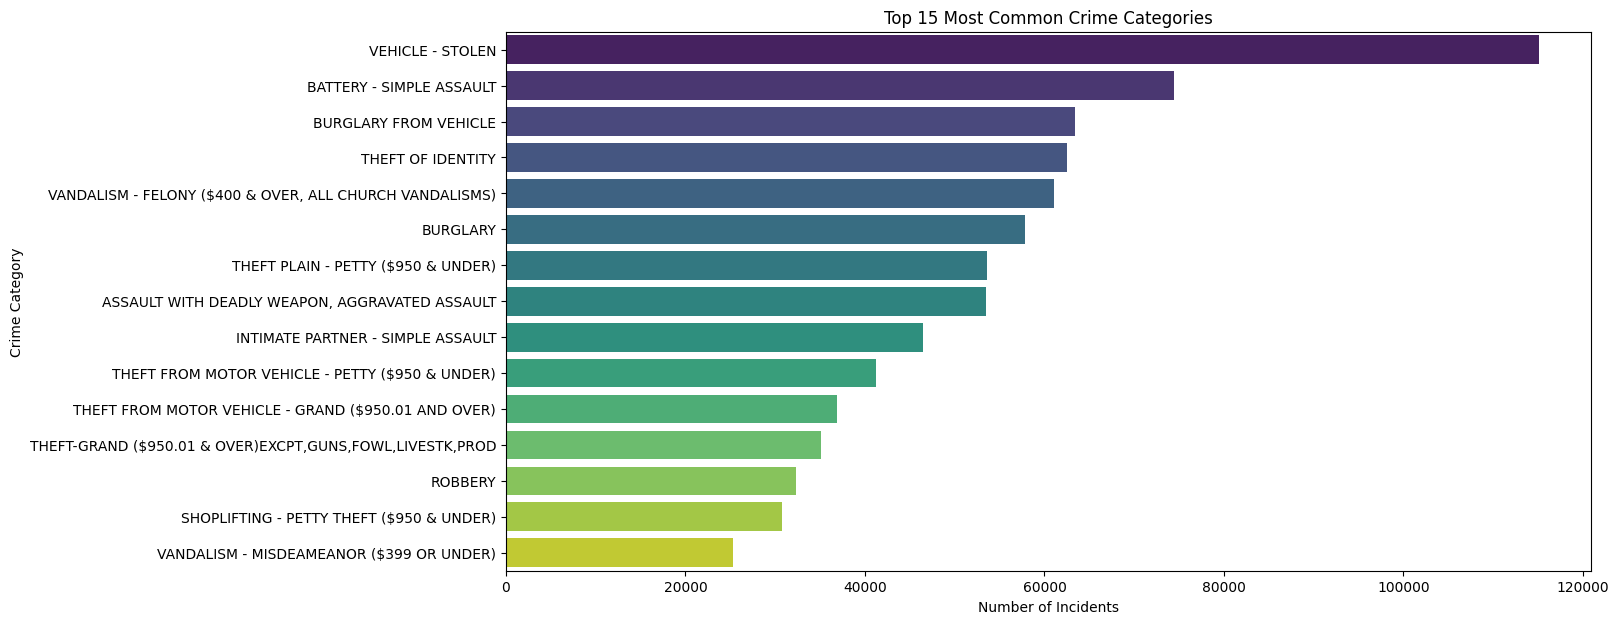

Crm Cd Desc
VEHICLE - STOLEN                                            115127
BATTERY - SIMPLE ASSAULT                                     74465
BURGLARY FROM VEHICLE                                        63460
THEFT OF IDENTITY                                            62511
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)      61028
BURGLARY                                                     57856
THEFT PLAIN - PETTY ($950 & UNDER)                           53603
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT               53502
INTIMATE PARTNER - SIMPLE ASSAULT                            46489
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)              41263
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)          36908
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     35111
ROBBERY                                                      32308
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                     30805
VANDALISM - MISDEAMEANOR ($399 OR UNDER)          

In [30]:
# 6.2 Crime Counts by Category

# For the first visualization, I want to see how many times each crime category
# appears in the dataset. The 'Crm Cd Desc' column contains the description of
# the crime type, so counting the occurrences of each value gives me a clear
# picture of which crimes are most common.
#
# I sort the counts in descending order so the most frequent crimes appear at the top.
# This makes the chart easier to read and interpret.

crime_counts = clean_df['Crm Cd Desc'].value_counts().sort_values(ascending=False)

# Plotting the top 15 crime categories to keep the visualization readable.
plt.figure(figsize=(14, 7))
sns.barplot(x=crime_counts.head(15).values, y=crime_counts.head(15).index, palette="viridis")

plt.title("Top 15 Most Common Crime Categories")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Category")

plt.show()

crime_counts.head(15)


### What the Results Show
The bar chart shows that **vehicle-related crimes** and **simple assaults** make up a large portion of the dataset. The category **`VEHICLE - STOLEN`** is the most common overall, which lines up with the fact that auto theft is a major issue in Los Angeles.

Categories like **`BATTERY - SIMPLE ASSAULT`** and **`BURGLARY FROM VEHICLE`** also appear near the top, showing that both personal and property crimes are heavily represented.

One interesting detail is how high **`THEFT OF IDENTITY`** ranks. This suggests that non-physical crimes are also a significant part of the dataset.

Both **felony** and **misdemeanor** vandalism appear in the top 15 (`VANDALISM - FELONY` and `VANDALISM - MISDEMEANOR`), which shows that property damage is consistently reported across the city.

Overall, the distribution is dominated by **theft**, **assault**, and **vehicle-related crimes**. This gives me a clear direction for the next steps in the analysis, especially when comparing crime types across different areas or time periods.
